In [147]:
import pandas as pd
df=pd.read_csv("/content/Churn_Modelling.csv")

In [148]:
df.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [149]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [150]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [151]:
df.duplicated().sum()

np.int64(0)

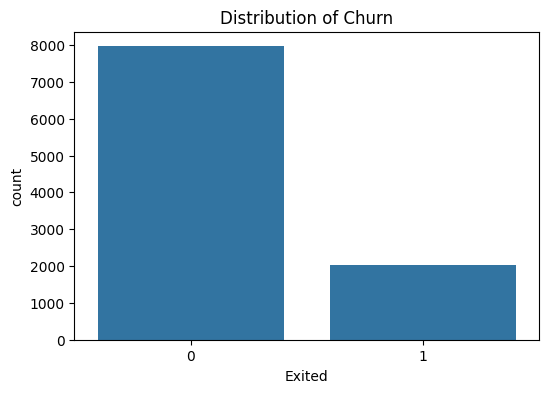

In [152]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Exited')
plt.title('Distribution of Churn')
plt.show()

array([[<Axes: title={'center': 'RowNumber'}>,
        <Axes: title={'center': 'CustomerId'}>,
        <Axes: title={'center': 'CreditScore'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Tenure'}>,
        <Axes: title={'center': 'Balance'}>],
       [<Axes: title={'center': 'NumOfProducts'}>,
        <Axes: title={'center': 'HasCrCard'}>,
        <Axes: title={'center': 'IsActiveMember'}>],
       [<Axes: title={'center': 'EstimatedSalary'}>,
        <Axes: title={'center': 'Exited'}>, <Axes: >]], dtype=object)

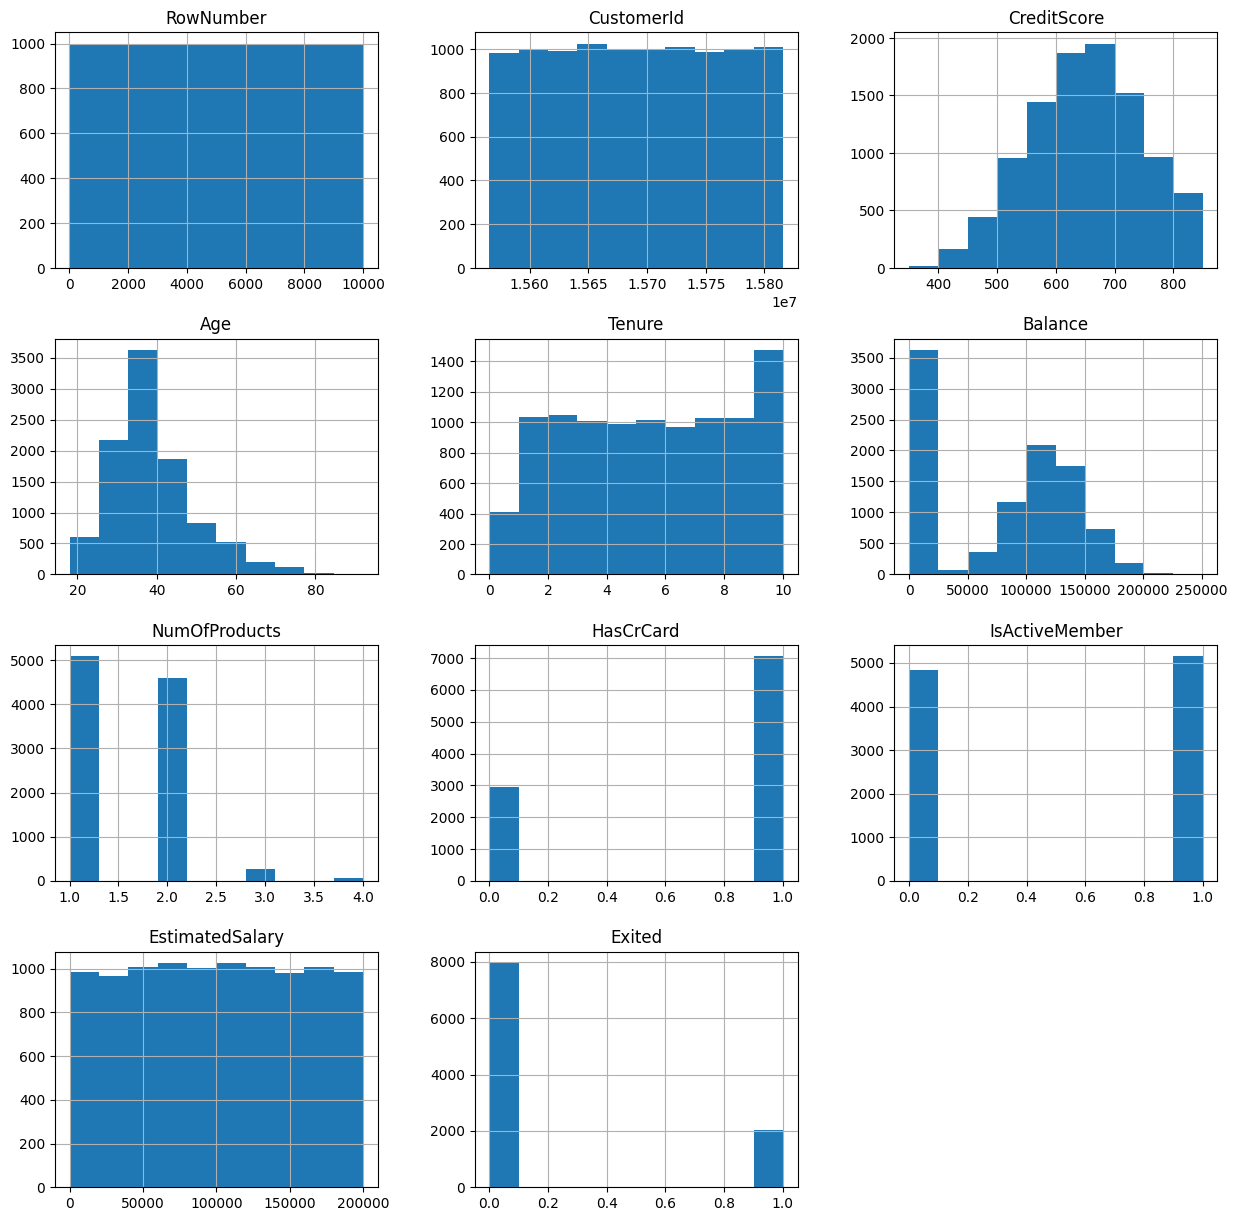

In [153]:
df.hist(figsize=(15, 15))

In [154]:
df['Geography'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [155]:
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

In [156]:
df.duplicated().sum()

np.int64(0)

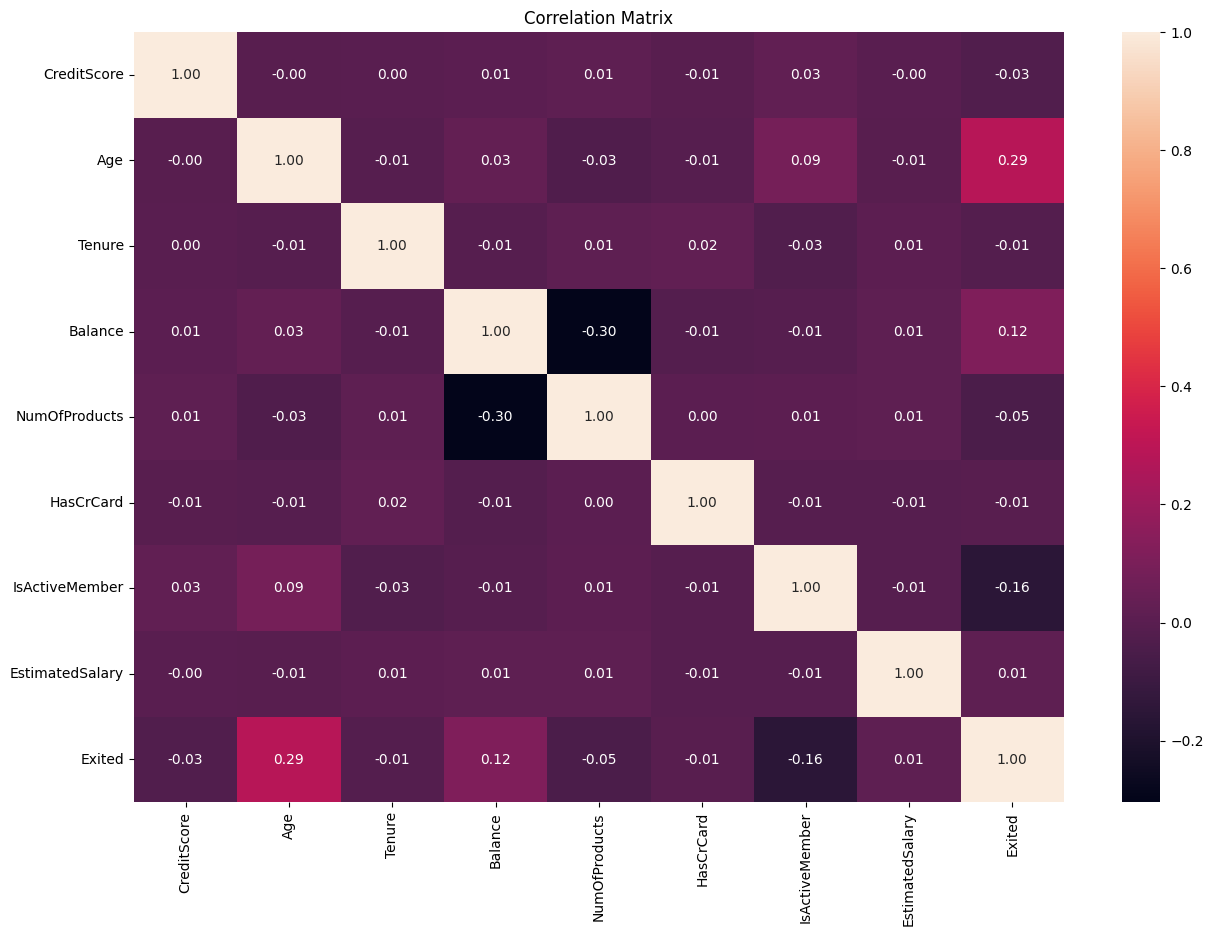

In [157]:
plt.figure(figsize=(15, 10))
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [158]:
df['Gender'] = df['Gender'].map({'Male' : 0, 'Female' : 1})

In [159]:
df = pd.get_dummies(df, columns=['Geography'], dtype=int)

In [160]:
df

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,1,42,2,0.00,1,1,1,101348.88,1,1,0,0
1,608,1,41,1,83807.86,1,0,1,112542.58,0,0,0,1
2,502,1,42,8,159660.80,3,1,0,113931.57,1,1,0,0
3,699,1,39,1,0.00,2,0,0,93826.63,0,1,0,0
4,850,1,43,2,125510.82,1,1,1,79084.10,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,0,39,5,0.00,2,1,0,96270.64,0,1,0,0
9996,516,0,35,10,57369.61,1,1,1,101699.77,0,1,0,0
9997,709,1,36,7,0.00,1,0,1,42085.58,1,1,0,0
9998,772,0,42,3,75075.31,2,1,0,92888.52,1,0,1,0


In [161]:
from sklearn.model_selection import train_test_split
x=df.drop(['Exited'],axis=1)
y=df['Exited']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [162]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [163]:
pd.DataFrame(x_train).head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,0.356500,-0.913248,-0.655786,0.345680,-1.218471,0.808436,0.649203,0.974817,1.367670,1.001501,-0.579467,-0.576388
1,-0.203898,-0.913248,0.294938,-0.348369,0.696838,0.808436,0.649203,0.974817,1.661254,-0.998501,1.725723,-0.576388
2,-0.961472,-0.913248,-1.416365,-0.695393,0.618629,-0.916688,0.649203,-1.025834,-0.252807,-0.998501,-0.579467,1.734942
3,-0.940717,1.094993,-1.131148,1.386753,0.953212,-0.916688,0.649203,-1.025834,0.915393,1.001501,-0.579467,-0.576388
4,-1.397337,-0.913248,1.625953,1.386753,1.057449,-0.916688,-1.540351,-1.025834,-1.059600,1.001501,-0.579467,-0.576388


In [164]:
x_train.shape

(8000, 12)

In [165]:
import tensorflow as tf
import keras
from keras.models import Sequential, Model
from keras.layers import Dense, BatchNormalization, Dropout, Input


In [166]:
#model = Sequential()

# model.add(Dense(16, activation='relu',input_shape=(12,) ))
# model.add(Dropout(0.2))
# model.add(Dense(8, activation='relu'))
# model.add(Dense(1, activation='sigmoid'))

In [167]:
# model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [168]:
# model.summary()

In [169]:
# history = model.fit(x_train, y_train, epochs=30, verbose=1, validation_split=0.2, batch_size=32)

In [170]:
!pip install optuna

In [171]:
import optuna
def objective(trial):
    n_layers = trial.suggest_int('n_layers', 1, 3)
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)

    model = Sequential()

    for i in range(n_layers):
        num_hidden = trial.suggest_int(f'n_units_l{i}', 8, 64)

        if i == 0:
            model.add(Dense(num_hidden, activation='relu', input_shape=(x_train.shape[1],)))
        else:
            model.add(Dense(num_hidden, activation='relu'))

        model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation='sigmoid'))

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    history = model.fit(
        x_train,
        y_train,
        validation_split=0.2,
        epochs=20,
        batch_size=32,
        verbose=0
    )

    return max(history.history['val_accuracy'])

study = optuna.create_study(direction='maximize')

study.optimize(objective, n_trials=30)

print(f"Best Validation Accuracy: {study.best_value * 100:.2f}%")
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2026-08-14 12:02:43,676] A new study created in memory with name: no-name-199ce416-08e4-4f9b-93c6-474ca61a0142
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[I 2026-08-14 12:03:11,063] Trial 0 finished with value: 0.8600000143051147 and parameters: {'n_layers': 2, 'dropout_rate': 0.49780030804455644, 'learning_rate': 0.0034938534330939686, 'n_units_l0': 59, 'n_units_l1': 36}. Best is trial 0 with value: 0.8600000143051147.
[I 2026-08-14 12:03:22,981] Trial 1 finished with value: 0.859375 and parameters: {'n_layers': 1, 'dropout_rate': 0.12688776267001442, 'learning_rate': 0.008719412498347278, 'n_units_l0': 46}. Best is trial 0 with value: 0.8600000143051147.
[I 2026-08-14 12:03:36,304] Trial 2 finishe

Best Validation Accuracy: 87.06%
Best Hyperparameters:
  n_layers: 3
  dropout_rate: 0.28288576086340467
  learning_rate: 0.0056144031475813885
  n_units_l0: 24
  n_units_l1: 45
  n_units_l2: 44


In [177]:
final_model = Sequential()

final_model.add(Dense(24, activation='relu', input_shape=(12,)))
final_model.add(Dropout(0.2829))
final_model.add(Dense(45, activation='relu'))
final_model.add(Dropout(0.2829))
final_model.add(Dense(44, activation='relu'))
final_model.add(Dropout(0.2829))
final_model.add(Dense(1, activation='sigmoid'))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0056)
final_model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

history = final_model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

test_loss, test_accuracy = final_model.evaluate(x_test, y_test, verbose=0)
print(f"\n Final Test Accuracy: {test_accuracy * 100:.2f}% ")

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7989 - loss: 0.4670 - val_accuracy: 0.8256 - val_loss: 0.4110
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8231 - loss: 0.4300 - val_accuracy: 0.8462 - val_loss: 0.3710
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8380 - loss: 0.4051 - val_accuracy: 0.8481 - val_loss: 0.3661
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8394 - loss: 0.3866 - val_accuracy: 0.8581 - val_loss: 0.3482
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8431 - loss: 0.3802 - val_accuracy: 0.8600 - val_loss: 0.3516
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8466 - loss: 0.3716 - val_accuracy: 0.8612 - val_loss: 0.3521
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8525 - loss: 0.3703 - val_accuracy: 0.8587 - val_loss: 0.3477
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8492 - loss: 0.3703 - val_accuracy: 0.8556 - val_